# Quantification of breaks in coordiantion

This code calculates the size and duration of breaks in cell coordination along the cell perimeter by detecting the region of the discontinuity using the AFT method, adapted from Marcotti S. et al., Frontiers in Computer Science, 2021 (https://doi.org/10.3389/fcomp.2021.745831)

**Input:**

*file_directory*: Path to folder containing the kymograph pkl file

*file_name*: The name of the kymograph pkl file 

*input_parameters_path*: The path to the file with the input parameters

**Output:**

*contours_corrected_units.csv*: A csv file with the detected contours of the gaps (scale: μm and sec)

*discontinuities.csv* : A csv file with the measured duration and size of the discontinuity detected


In [1]:
import os
import csv
import cv2
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib as mpl
import matplotlib.colors as mcolors
from skimage import measure
from scipy.ndimage import binary_fill_holes, label
from scipy.ndimage import label, find_objects
from scipy.ndimage import gaussian_filter
import numpy.matlib as matlib

from functions import image_local_order
### The imported function, image_local_order, (and its helper functions) is copied from:
    # Marcotti S. et al., Frontiers in Computer Science, 2021 (2021), DOI: https://doi.org/10.3389/fcomp.2021.745831, 
    # MIT License (https://github.com/OakesLab/AFT-Alignment_by_Fourier_Transform).
    # Minor modifications were made for the detection of reorientations and breaks in coordiantion
    # in our analysis. 


### Input

In [2]:
### Path to kymograph:
file_directory  = "C:\\Users\\kourkoul\\SCRIPTS\\Paper_scripts\\example_data\\"
file_name       = "corrected_kymograph.pkl" 

### Reading the parameters file
input_parameters_path = file_directory + "parameters.csv"
input_parameters = pd.read_csv(input_parameters_path)

### Pixel size and framerate of timelapse:
pixel_size = input_parameters["pixel_size"][0]  # μm 
fps        = input_parameters["fps"][0]         # frame rate

### Parameters related to AFT and thresholds 
window_size = input_parameters["window_size"][0]
overlap     = input_parameters["overlap"][0]
threshold   = input_parameters["threshold"][0]
min_size    = input_parameters["min_size"][0]

kymograph_file = file_directory + file_name
kymograph = pd.read_pickle(kymograph_file)

output_path = file_directory + "\\gap_measurements\\"
if not os.path.exists(output_path):
    os.makedirs(output_path)

### Pre-processing

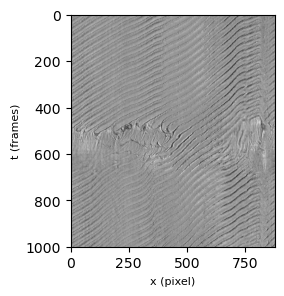

In [3]:
### Plot kymograph
fontsize = 8
aspect_ratio = 1 

fig, ax = plt.subplots(figsize=(4,4))
plt.subplots_adjust(left=0.1, bottom=0.3) 
im = ax.imshow(kymograph, cmap="gray",aspect = aspect_ratio, origin = 'lower', extent=[kymograph.columns[0], kymograph.columns[-1], kymograph.index[0], kymograph.index[-1]])
plt.gca().invert_yaxis()
plt.xlabel('x (pixel)', fontsize = fontsize)
plt.ylabel('t (frames)', fontsize = fontsize)
plt.show()

Text(0, 0.5, 't (frames)')

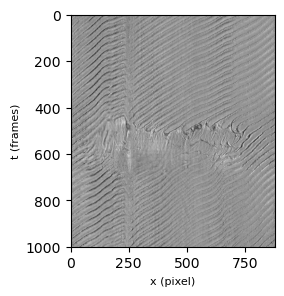

In [6]:
### if gap falls on edge, change point of reference
shift = 300
kymograph.values[:] = np.roll(kymograph.values, shift=shift, axis=1)
### To load a prepared kymograph:
## kymograph = pd.read_pickle(file_directory + "rolled_kymograph.pkl")

# Create figure and axis
fig, ax = plt.subplots(figsize=(4,4))
plt.subplots_adjust(left=0.1, bottom=0.3)  # Adjust layout for sliders
im = ax.imshow(kymograph, cmap="gray", aspect = aspect_ratio, origin = 'lower', extent=[kymograph.columns[0], kymograph.columns[-1], kymograph.index[0], kymograph.index[-1]])
plt.gca().invert_yaxis()
plt.xlabel('x (pixel)', fontsize = fontsize)
plt.ylabel('t (frames)', fontsize = fontsize)


In [5]:
### Data with high fps (>1000) are downsampled to fps = 1000
### e.g. for fps = 6000
## kymograph_original = kymograph
# data = kymograph.to_numpy()
# data = data[:(data.shape[0] // 6) * 6, :]
# downscaled = data.reshape(-1, 6, data.shape[1]).mean(axis=1)
 #kymograph = downscaled

### Gap detection

In [7]:
rpos, cpos, x, y, u, v, im_theta, im_eccentricity = image_local_order(
    kymograph, 
    aspect_ratio, 
    window_size, 
    overlap, 
    intensity_thresh=-np.inf,         # Allow all intensity levels
    eccentricity_thresh=0,            # Allow all eccentricities
    save_path = output_path,
    plot_overlay=True, 
    plot_angles=True, 
    plot_eccentricity=False,
    save_figures=False
)

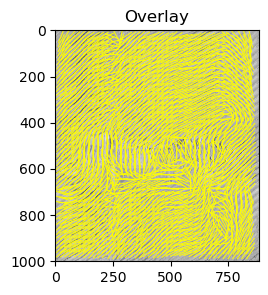

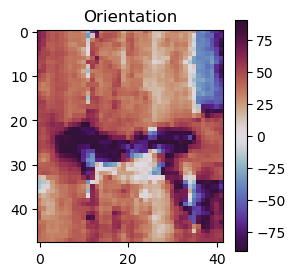

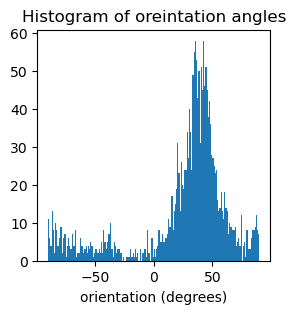

In [8]:
### Visualization of detection
plt.figure(figsize=(3,3))
plt.imshow(kymograph, cmap='Greys_r', aspect = aspect_ratio)
plt.quiver(x,y,u,v, color='yellow', pivot='mid', scale_units='xy', scale=overlap/2, headaxislength=0, headlength=0, width=0.005)
plt.title('Overlay')
plt.show()

im_theta_degrees = im_theta * 180 / np.pi
plt.figure(figsize=(3,3))
plt.imshow(im_theta_degrees, vmin=-90, vmax=90, cmap='twilight_shifted', aspect = aspect_ratio) 
plt.colorbar()
plt.title('Orientation')
plt.show()

plt.figure(figsize=(3,3))
plt.title("Histogram of oreintation angles")
plt.hist(im_theta_degrees.flatten(), bins=180)
plt.xlabel("orientation (degrees)")
plt.show()


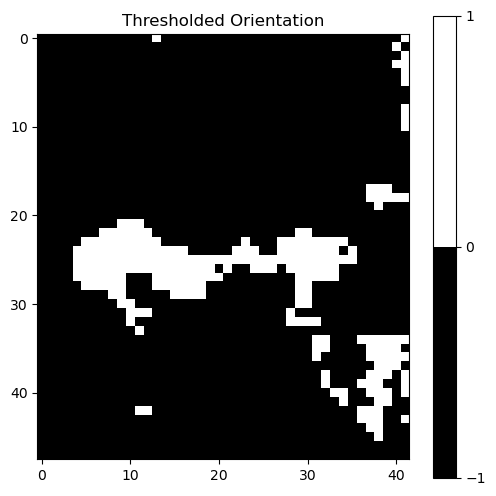

In [9]:
### Thresholding to isolate the gap 
thresholded_data = np.where((im_theta_degrees < -threshold) | (im_theta_degrees > threshold), 1, -1)

colors = [(0, 0, 0), (1, 1, 1)]  # Blue for -1, Red for 1
n_bins = 100  # Number of bins for the colormap
cmap = mcolors.ListedColormap(colors)

# Normalize the thresholded data
norm = mcolors.BoundaryNorm(boundaries=[-1, 0, 1], ncolors=n_bins)

# Plot the thresholded data with the custom colormap
plt.figure(figsize=(6, 6))
plt.imshow(thresholded_data, cmap=cmap, norm=norm, aspect = aspect_ratio)
plt.colorbar()
plt.title('Thresholded Orientation')
plt.show()

In [10]:
### Filter small discontinuities and false detections before creating bounding boxes:
structure = np.ones((3, 3), dtype=int) 
labeled_array, num_features = label(thresholded_data == 1, structure=structure)

bounding_boxes = []

for i in range(1, num_features + 1):
    slice_yx = find_objects(labeled_array == i)[0]  
    region = labeled_array[slice_yx] == i
    if np.sum(region) >= min_size:
        bounding_boxes.append(slice_yx)

cell_perimeter = kymograph.columns.astype(float).max()     


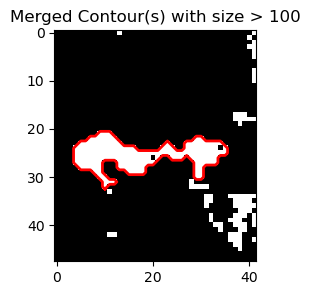

In [11]:
# Fill holes so thin parts stay connected
filled_mask = binary_fill_holes(thresholded_data > 0)

# Label connected components
labeled_array, num_labels = label(filled_mask)

# Calculate sizes of each labeled region
sizes = np.bincount(labeled_array.ravel())

# Create a new mask keeping only large regions
filtered_mask = np.zeros_like(filled_mask)
for label_val in range(1, num_labels + 1):
    if sizes[label_val] >= min_size:
        filtered_mask[labeled_array == label_val] = 1

# Find contours on the filtered mask
contours = measure.find_contours(filtered_mask, level=0.5)

# Plot
plt.figure(figsize=(3,3))
plt.imshow(thresholded_data, cmap='gray', aspect=aspect_ratio)
for contour in contours:
    plt.plot(contour[:, 1], contour[:, 0], linewidth=2, color='red')

plt.title(f"Merged Contour(s) with size > {min_size}")
plt.show()


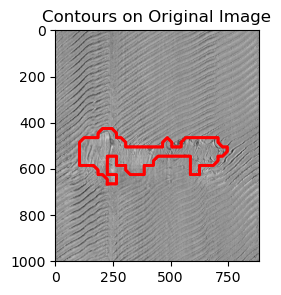

In [12]:
contours_corrected = []

for contour in contours:
    corrected_contour = []
    
    for y_win, x_win in contour:
        y_idx = int(round(y_win))
        x_idx = int(round(x_win))
        
        # Check bounds on rpos and cpos
        if 0 <= y_idx < len(rpos) and 0 <= x_idx < len(cpos):
            y_orig = rpos[y_idx]
            x_orig = cpos[x_idx]
            corrected_contour.append((y_orig, x_orig))

    if corrected_contour:
        contours_corrected.append(np.array(corrected_contour))
    if corrected_contour:
        contours_corrected.append(np.array(corrected_contour))
        

plt.figure(figsize=(3,3))
plt.imshow(kymograph, aspect = aspect_ratio, cmap='gray')  

for contour in contours_corrected:
    plt.plot(contour[:, 1], contour[:, 0], linewidth=2, color='red')

plt.title("Contours on Original Image")
plt.show()

### Rescale the kymograph and the contour to μm and seconds

In [13]:
num_frames = kymograph.shape[0]
num_pixels = kymograph.shape[1]

rescaled_kymograph = kymograph

# # Rescale the index by fps
new_index = pd.Index(np.arange(num_frames) / fps)
# Rescale the columns by pixel_size
new_columns = pd.Index(np.arange(num_pixels) * pixel_size)
    
# # Reindex the DataFrame
rescaled_kymograph = kymograph.copy()
rescaled_kymograph.index = new_index
rescaled_kymograph.columns = new_columns
rescaled_kymograph.index.name = 'time (sec)'
rescaled_kymograph.columns.name = 'position along the cilia (\u03BCm)'


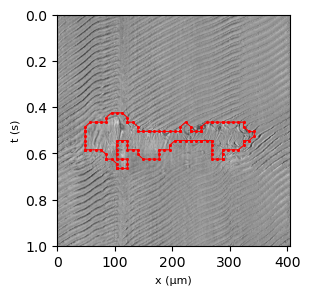

In [14]:
contours_correct_units = [
    np.column_stack((
        contour[:, 0] / fps,           
        contour[:, 1] * pixel_size      
    ))
    for contour in contours_corrected
]

fontsize = 8
plt.figure(figsize=(3,3))
plt.imshow(rescaled_kymograph, aspect='auto', origin='lower', cmap="gray", extent=[rescaled_kymograph.columns[0],rescaled_kymograph.columns[-1], rescaled_kymograph.index[0], rescaled_kymograph.index[-1]])
plt.gca().invert_yaxis()
plt.xlabel('x (\u03BCm)', fontsize = fontsize)
plt.ylabel('t (s)', fontsize = fontsize)

for contour in contours_correct_units:
    plt.scatter(contour[:, 1], contour[:, 0],  s=1, color= "red") 
    plt.plot(contour[:, 1], contour[:, 0], linewidth=0.5, color='red')
    
plt.show()

### Quantify size and duration

Duration: 0.24 sec
Maximum width in space: 294.40 um
Duration: 0.24 sec
Maximum width in space: 294.40 um


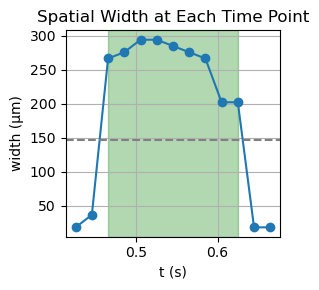

In [15]:
durations = []
max_widths = []
fwhm_durations = []
start_timepoints = []
end_timepoints = []

j=1

for contour in contours_correct_units:

    x = contour[:, 1]
    y = contour[:, 0]
    x_min = np.min(x)
    x_max = np.max(x)
    
    # Duration (time extent)
    duration = np.max(y) - np.min(y)

    # Max width at each unique time
    unique_times = np.unique(y)
    widths = []
    valid_times = []
    
    for t in unique_times:
        x_at_t = x[y == t]
        if len(x_at_t) > 1:
            width = np.max(x_at_t) - np.min(x_at_t)
        else: 
            width = 0
        widths.append(width)
         
        valid_times.append(t)
    
    max_width = max(widths)
    half_max = max_width * 0.5

    durations.append(duration)
    max_widths.append(max_width)
    
    above_half = np.array(widths) >= half_max
    if np.any(above_half):
        start_half = valid_times[np.argmax(above_half)]
        end_half = valid_times[len(valid_times) - np.argmax(above_half[::-1]) - 1]
        duration_half_max = end_half - start_half
        x_at_start = x[y == start_half]
        width_at_start = np.max(x_at_start) - np.min(x_at_start)
    else:
        duration_half_max = 0
    
    start_timepoints.append(start_half)
    end_timepoints.append(end_half)
    
    fwhm_durations.append(duration_half_max)
    
    df_widths = pd.DataFrame({
    'time (s)': unique_times,
    'width (um)': widths})

    # Save to CSV (one file per contour)
    df_widths.to_csv(output_path + f"contour_{j}_width_vs_time.csv", index=False)
    
    print(f"Duration: {duration:.2f} sec")
    print(f"Maximum width in space: {max_width:.2f} um")
    j = j+1

# Plot
plt.figure(figsize=(3,3))
plt.plot(unique_times, widths, marker='o')
plt.axhline(half_max, color='gray', linestyle='--', label='50% Max Width')
if duration_half_max > 0:
    plt.axvspan(start_half, end_half, color='green', alpha=0.3, label='FWHM Duration')
plt.title('Spatial Width at Each Time Point')
plt.xlabel('t (s)')
plt.ylabel('width (\u03BCm)')
plt.grid(True)
plt.tight_layout()
plt.show()



### Saving detected contours and results

In [16]:
with open(output_path + "\\contours_corrected.csv", "w", newline='') as csvfile:
    writer = csv.writer(csvfile)
    for i, contour in enumerate(contours_corrected):
        for y, x in contour:
            writer.writerow([i, y, x])  

with open(output_path + "contours_correct_units.csv", "w", newline='') as csvfile:
    writer = csv.writer(csvfile)
    for i, contour in enumerate(contours_correct_units):
        for y, x in contour:
            writer.writerow([i, y, x])  

In [17]:
cell_perimeter = rescaled_kymograph.columns.astype(float).max()  

for i in range(len(durations)):
    full_duration_sec = np.round(durations[i],3)
    duration_for_half_max_sec = np.round(fwhm_durations[i],3)
    gap_um = np.round(max_widths[i],3)
    percentage = gap_um/cell_perimeter*100
    start = np.round(start_timepoints[i], 3)
    end = np.round(end_timepoints[i], 3)
    
    filename = output_path + "\\discontinuities_contour_" + str(i+1) + ".csv"
    file_exists = os.path.isfile(filename)

    with open(filename, 'a', newline='') as f:
        writer = csv.writer(f)
    
        # Write headers only once
        if not file_exists:
            writer.writerow([
                 'cell_perimeter_um',
                'full_duration_sec', 'start_fwhm_sec', 'end_fwhm_sec', 'duration_for_half_max_sec',  'gap_um', 'percentage_perimeter'
            ])
    
        # Always write data row
        writer.writerow([
            cell_perimeter,
            full_duration_sec, start, end, duration_for_half_max_sec, gap_um, percentage
        ])
